# Unified Model Comparison: PDE vs Supermodel vs SuperNet

This script compares three approaches to tumor dynamics modeling:
1. **PDE** - 2D reaction-diffusion (ground truth)
2. **Supermodel** (ODE + NN correction) - Trained on PDE tumor burden
3. **SuperNet** (PINN) - Physics-informed neural network

Train on 40% of time, test on 60%.

In [46]:
# =============================================================================
# SECTION 1: Configuration
# =============================================================================
import os
import sys
import json
import time
import math
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm

# -----------------------------------------------------------------------------
# MAIN CONFIGURATION FLAG
# -----------------------------------------------------------------------------
DOSING_MODE = "bolus"  # Switch between "bolus" | "infusion"

# Simulation parameters
T_END = 10.0
TRAIN_FRACTION = 0.4
N_GRID = 48  # PDE grid resolution (reduced for speed)

# Training hyperparameters (balanced for speed + quality)
SUPERMODEL_EPOCHS = 50
SUPERNET_EPOCHS = 1200
LEARNING_RATE = 3e-3  # Higher LR for faster convergence

# Output directories
Path("figs").mkdir(exist_ok=True)
Path("out").mkdir(exist_ok=True)

# Device detection (MPS -> CUDA -> CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Metal (MPS) acceleration")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA acceleration")
else:
    device = torch.device("cpu")
    print("Using CPU (no GPU acceleration)")

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Import PDE module components
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("Warning: SciPy not available - semi-implicit solver disabled")

Using Apple Metal (MPS) acceleration


In [47]:
# =============================================================================
# SECTION 2: PDE Ground Truth Generation
# =============================================================================

@dataclass
class PDEParams:
    """Parameters for the 2D PDE tumor model."""
    # Diffusion coefficients
    D_S: float = 0.0       # Sensitive cells (typically very slow)
    D_R: float = 0.0       # Resistant cells
    D_I: float = 0.0       # Immune cells
    D_C: float = 1.5e-2    # Drug diffuses fastest

    # Growth rates (moderate for smooth dynamics)
    rho_S: float = 0.08    # Sensitive cell growth
    rho_R: float = 0.05    # Resistant cell growth (slower)
    K: float = 1.0         # Carrying capacity

    # Cytotoxicity (strong drug effect on S, weak on R)
    alpha_S: float = 0.6   # Drug kill rate for S
    alpha_R: float = 0.08  # Drug kill rate for R (much lower)

    # Immunology (moderate immune response)
    gamma_S: float = 0.03
    gamma_R: float = 0.02
    sigma: float = 0.04
    delta: float = 0.08

    # Pharmacokinetics
    lam: float = 0.15      # Drug clearance rate
    beta: float = 0.0      # Drug consumption by cells

    # Resistance dynamics (Hill function)
    mu_max: float = 0.03   # Lower mutation rate for smoother curves
    C50: float = 0.3
    m_hill: int = 2

    # Dosing parameters
    dose_type: str = "bolus_periodic"
    dose_A: float = 0.8    # Moderate dose
    dose_period: float = 3.0  # Every 3 time units
    infusion_rate: float = 0.1


@dataclass
class Grid:
    """2D computational grid."""
    Nx: int
    Ny: int
    Lx: float = 1.0
    Ly: float = 1.0

    def __post_init__(self):
        self.dx = self.Lx / (self.Nx - 1)
        self.dy = self.Ly / (self.Ny - 1)
        self.x = np.linspace(0.0, self.Lx, self.Nx)
        self.y = np.linspace(0.0, self.Ly, self.Ny)
        self.X, self.Y = np.meshgrid(self.x, self.y, indexing="xy")


def mu_of_C(C, mu_max, C50, m):
    """Hill function for resistance acquisition rate."""
    C_nonneg = np.maximum(C, 0.0)
    ratio = np.power(C_nonneg / (C50 + 1e-12), m)
    return mu_max * (ratio / (1.0 + ratio))


def dosing_term(t, p: PDEParams):
    """Compute drug input rate at time t."""
    if p.dose_type == "none":
        return 0.0
    if p.dose_type == "infusion_const":
        return p.infusion_rate
    if p.dose_type == "bolus_periodic":
        tau = 0.01 * p.dose_period
        phase = t % p.dose_period
        return p.dose_A / tau if phase < tau else 0.0
    return 0.0


def laplacian_neumann(U, dx, dy):
    """5-point Laplacian with Neumann boundary conditions."""
    Ux_f = np.pad(U, ((0, 0), (1, 1)), mode="edge")
    Uy_f = np.pad(U, ((1, 1), (0, 0)), mode="edge")
    Uc = U
    Uxx = (Ux_f[:, 2:] - 2*Uc + Ux_f[:, :-2]) / (dx*dx)
    Uyy = (Uy_f[2:, :] - 2*Uc + Uy_f[:-2, :]) / (dy*dy)
    return Uxx + Uyy


def init_pde_fields(grid: Grid):
    """Initialize PDE fields: tumor dome in center."""
    X, Y = grid.X, grid.Y
    r = np.sqrt((X - 0.5*grid.Lx)**2 + (Y - 0.5*grid.Ly)**2)
    S0 = 0.5 * np.exp(-(r/0.15)**2)
    R0 = 0.05 * np.exp(-((r - 0.2)/0.1)**2)
    I0 = 0.02 * np.ones_like(S0)
    C0 = np.zeros_like(S0)
    return S0, R0, I0, C0


def reaction_terms(S, R, I, C, p: PDEParams):
    """Compute reaction terms (without diffusion)."""
    N = S + R
    growth_S = p.rho_S * S * (1.0 - N / p.K)
    growth_R = p.rho_R * R * (1.0 - N / p.K)

    kill_S = p.alpha_S * C * S + p.gamma_S * I * S
    kill_R = p.alpha_R * C * R + p.gamma_R * I * R

    mu = mu_of_C(C, p.mu_max, p.C50, p.m_hill)

    dS = growth_S - kill_S - mu * S
    dR = growth_R - kill_R + mu * S
    dI = p.sigma * N - p.delta * I
    dC = -p.lam * C - p.beta * C * N

    return dS, dR, dI, dC


def stability_dt(grid: Grid, p: PDEParams, safety=0.24):
    """CFL condition for explicit solver."""
    Dmax = max(p.D_S, p.D_R, p.D_I, p.D_C)
    if Dmax <= 0:
        return 1e-2
    return safety * min(grid.dx**2, grid.dy**2) / (4.0*Dmax + 1e-12)


def laplacian_1d_neumann(n, h):
    """1D Laplacian matrix with Neumann BC."""
    main = -2.0 * np.ones(n)
    off = 1.0 * np.ones(n-1)
    main[0] = -1.0
    main[-1] = -1.0
    L = sp.diags([off, main, off], offsets=[-1, 0, 1], format="csr") / (h*h)
    return L


def build_diffusion_operators(Nx, Ny, dx, dy, D, dt, theta=0.5):
    """Build implicit diffusion operators."""
    Ix = sp.eye(Nx, format="csr")
    Iy = sp.eye(Ny, format="csr")
    Lx = laplacian_1d_neumann(Nx, dx)
    Ly = laplacian_1d_neumann(Ny, dy)
    L2 = sp.kron(Iy, Lx, format="csr") + sp.kron(Ly, Ix, format="csr")
    A = sp.eye(Nx*Ny, format="csr") - theta * dt * D * L2
    B = sp.eye(Nx*Ny, format="csr") + (1.0 - theta) * dt * D * L2
    return A, B


def run_pde_simulation(grid: Grid, p: PDEParams, T: float, save_dt: float = 0.1):
    """
    Run 2D PDE simulation using semi-implicit solver.
    Returns time array and trajectory of spatially-integrated quantities.
    """
    S, R, I, C = init_pde_fields(grid)

    # Determine timestep
    dt = 2.0e-2 if SCIPY_AVAILABLE else stability_dt(grid, p)
    steps = int(math.ceil(T / dt))
    save_every = max(1, int(save_dt / dt))

    # Build system matrices for semi-implicit solver
    sys_mats = {}
    if SCIPY_AVAILABLE and p.D_C > 0:
        A_C, B_C = build_diffusion_operators(
            grid.Nx, grid.Ny, grid.dx, grid.dy, p.D_C, dt, theta=0.5
        )
        sys_mats["A_C"] = A_C
        sys_mats["B_C"] = B_C

    # Storage for trajectory
    times = []
    S_int, R_int, I_int, C_int = [], [], [], []

    print(f"Running PDE simulation: {steps} steps, dt={dt:.4e}")

    for n in tqdm(range(steps), desc="PDE Simulation"):
        t_cur = n * dt

        # Reaction step
        fS, fR, fI, fC = reaction_terms(S, R, I, C, p)
        I_in = dosing_term(t_cur, p)

        S_r = np.clip(S + dt * fS, 0.0, None)
        R_r = np.clip(R + dt * fR, 0.0, None)
        I_r = np.clip(I + dt * fI, 0.0, None)
        C_r = np.clip(C + dt * (fC + I_in), 0.0, None)

        # Diffusion step for C (implicit)
        if SCIPY_AVAILABLE and p.D_C > 0:
            rhs = sys_mats["B_C"] @ C_r.ravel(order="C")
            C_new = spla.spsolve(sys_mats["A_C"], rhs).reshape(C_r.shape, order="C")
            C_new = np.clip(C_new, 0.0, None)
        else:
            # Explicit diffusion fallback
            if p.D_C > 0:
                diff_C = p.D_C * laplacian_neumann(C_r, grid.dx, grid.dy)
                C_new = np.clip(C_r + dt * diff_C, 0.0, None)
            else:
                C_new = C_r

        S, R, I, C = S_r, R_r, I_r, C_new

        # Save trajectory at intervals
        if n % save_every == 0 or n == steps - 1:
            dA = grid.dx * grid.dy
            times.append(t_cur)
            S_int.append(float(S.sum() * dA))
            R_int.append(float(R.sum() * dA))
            I_int.append(float(I.sum() * dA))
            C_int.append(float(C.sum() * dA))

    return {
        't': np.array(times),
        'S': np.array(S_int),
        'R': np.array(R_int),
        'I': np.array(I_int),
        'C': np.array(C_int),
        'TB': np.array(S_int) + np.array(R_int)  # Tumor Burden
    }

In [48]:
# =============================================================================
# SECTION 3: ODE Baseline Model
# =============================================================================

def mu_of_C_scalar(C, mu_max, C50, m):
    """Hill function (scalar version for ODE)."""
    C_nonneg = max(C, 0.0)
    ratio = (C_nonneg / (C50 + 1e-12)) ** m
    return mu_max * (ratio / (1.0 + ratio))


def ode_dosing(t, p: PDEParams):
    """Dosing input for ODE model."""
    if p.dose_type == "infusion_const":
        return p.infusion_rate
    if p.dose_type == "bolus_periodic":
        tau = 0.01 * p.dose_period
        phase = t % p.dose_period
        return p.dose_A / tau if phase < tau else 0.0
    return 0.0


def ode_rhs(y, t, p: PDEParams):
    """
    Spatially-averaged ODE model (matches PDE reaction terms, no diffusion).
    y = [S, R, I, C]
    """
    S, R, I, C = y
    S = max(S, 0.0)
    R = max(R, 0.0)
    I = max(I, 0.0)
    C = max(C, 0.0)

    N = S + R

    # Growth terms (logistic)
    growth_S = p.rho_S * S * (1.0 - N / p.K)
    growth_R = p.rho_R * R * (1.0 - N / p.K)

    # Kill terms
    kill_S = p.alpha_S * C * S + p.gamma_S * I * S
    kill_R = p.alpha_R * C * R + p.gamma_R * I * R

    # Resistance mutation
    mu = mu_of_C_scalar(C, p.mu_max, p.C50, p.m_hill)

    # ODE right-hand side
    dS = growth_S - kill_S - mu * S
    dR = growth_R - kill_R + mu * S
    dI = p.sigma * N - p.delta * I
    dC = -p.lam * C - p.beta * C * N + ode_dosing(t, p)

    return np.array([dS, dR, dI, dC])


def rk4_step(y, t, dt, rhs_func, p):
    """Single RK4 integration step."""
    k1 = rhs_func(y, t, p)
    k2 = rhs_func(y + 0.5*dt*k1, t + 0.5*dt, p)
    k3 = rhs_func(y + 0.5*dt*k2, t + 0.5*dt, p)
    k4 = rhs_func(y + dt*k3, t + dt, p)
    return y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)


def run_ode_simulation(p: PDEParams, T: float, dt: float = 0.01, y0: np.ndarray = None):
    """
    Run ODE simulation using RK4.
    Returns time array and trajectory.
    """
    if y0 is None:
        # Match PDE initial conditions (spatially integrated)
        grid = Grid(Nx=N_GRID, Ny=N_GRID)
        S0, R0, I0, C0 = init_pde_fields(grid)
        dA = grid.dx * grid.dy
        y0 = np.array([
            float(S0.sum() * dA),
            float(R0.sum() * dA),
            float(I0.sum() * dA),
            float(C0.sum() * dA)
        ])

    steps = int(T / dt)
    times = np.zeros(steps)
    trajectory = np.zeros((steps, 4))

    y = y0.copy()
    for i in range(steps):
        t = i * dt
        times[i] = t
        trajectory[i] = y
        y = rk4_step(y, t, dt, ode_rhs, p)
        y = np.clip(y, 0.0, None)

    return {
        't': times,
        'S': trajectory[:, 0],
        'R': trajectory[:, 1],
        'I': trajectory[:, 2],
        'C': trajectory[:, 3],
        'TB': trajectory[:, 0] + trajectory[:, 1]
    }

In [49]:
# =============================================================================
# SECTION 4: Supermodel (ODE + Neural Network Correction)
# =============================================================================

class CorrectionNetwork(nn.Module):
    """
    Neural network that learns corrections to ODE dynamics.
    Input: [S, R, I, C, t] -> Output: [dS, dR, dI, dC] corrections
    """
    def __init__(self, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 4)
        )
        # Initialize with moderate weights for faster learning
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight, gain=0.5)
                nn.init.zeros_(layer.bias)

    def forward(self, y, t):
        """
        y: tensor of shape (batch, 4) containing [S, R, I, C]
        t: tensor of shape (batch, 1) containing time
        """
        x = torch.cat([y, t], dim=-1)
        return self.net(x)


class Supermodel(nn.Module):
    """
    Hybrid model: dy/dt = f_ODE(y, t) + g_NN(y, t)
    """
    def __init__(self, params: PDEParams, hidden_dim: int = 64):
        super().__init__()
        self.params = params
        self.correction = CorrectionNetwork(hidden_dim)

        # Store parameters as tensors
        self.register_buffer('rho_S', torch.tensor(params.rho_S))
        self.register_buffer('rho_R', torch.tensor(params.rho_R))
        self.register_buffer('K', torch.tensor(params.K))
        self.register_buffer('alpha_S', torch.tensor(params.alpha_S))
        self.register_buffer('alpha_R', torch.tensor(params.alpha_R))
        self.register_buffer('gamma_S', torch.tensor(params.gamma_S))
        self.register_buffer('gamma_R', torch.tensor(params.gamma_R))
        self.register_buffer('mu_max', torch.tensor(params.mu_max))
        self.register_buffer('C50', torch.tensor(params.C50))
        self.register_buffer('m_hill', torch.tensor(float(params.m_hill)))
        self.register_buffer('sigma', torch.tensor(params.sigma))
        self.register_buffer('delta', torch.tensor(params.delta))
        self.register_buffer('lam', torch.tensor(params.lam))
        self.register_buffer('beta', torch.tensor(params.beta))

    def ode_rhs_torch(self, y, t):
        """ODE right-hand side in PyTorch."""
        S = y[:, 0:1]
        R = y[:, 1:2]
        I = y[:, 2:3]
        C = y[:, 3:4]

        N = S + R

        # Growth
        growth_S = self.rho_S * S * (1.0 - N / self.K)
        growth_R = self.rho_R * R * (1.0 - N / self.K)

        # Kill
        kill_S = self.alpha_S * C * S + self.gamma_S * I * S
        kill_R = self.alpha_R * C * R + self.gamma_R * I * R

        # Resistance
        ratio = torch.pow(torch.clamp(C, min=0) / (self.C50 + 1e-12), self.m_hill)
        mu = self.mu_max * ratio / (1.0 + ratio)

        # Dosing
        p = self.params
        if p.dose_type == "infusion_const":
            I_in = p.infusion_rate
        elif p.dose_type == "bolus_periodic":
            tau = 0.01 * p.dose_period
            phase = t % p.dose_period
            I_in = torch.where(phase < tau, p.dose_A / tau, torch.zeros_like(t))
        else:
            I_in = 0.0

        dS = growth_S - kill_S - mu * S
        dR = growth_R - kill_R + mu * S
        dI = self.sigma * N - self.delta * I
        dC = -self.lam * C - self.beta * C * N + I_in

        return torch.cat([dS, dR, dI, dC], dim=-1)

    def forward(self, y, t):
        """Combined dynamics: ODE + NN correction."""
        f_ode = self.ode_rhs_torch(y, t)
        f_nn = self.correction(y, t)
        return f_ode + f_nn

    def integrate(self, y0, times, dt=0.01):
        """Integrate the hybrid model using RK4."""
        T = times[-1]
        steps = int(T / dt)

        # Initialize
        y = y0.clone()

        # Storage at requested times
        t_idx = 0
        results = torch.zeros(len(times), 4, device=y0.device)

        for i in range(steps):
            t = i * dt
            t_tensor = torch.tensor([[t]], device=y.device, dtype=y.dtype)

            # Save at requested times
            while t_idx < len(times) and times[t_idx] <= t + dt/2:
                results[t_idx] = y.squeeze()
                t_idx += 1

            # RK4 step
            k1 = self(y, t_tensor)
            k2 = self(y + 0.5*dt*k1, t_tensor + 0.5*dt)
            k3 = self(y + 0.5*dt*k2, t_tensor + 0.5*dt)
            k4 = self(y + dt*k3, t_tensor + dt)
            y = y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
            y = torch.clamp(y, min=0.0)

        # Fill remaining
        while t_idx < len(times):
            results[t_idx] = y.squeeze()
            t_idx += 1

        return results


def train_supermodel(model: Supermodel, pde_data: dict, train_mask: np.ndarray,
                     epochs: int = 2000, lr: float = 1e-3):
    """
    Train the Supermodel to match PDE tumor burden on training time points.
    """
    optimizer = torch.optim.Adam(model.correction.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    # Prepare data
    times = torch.tensor(pde_data['t'], dtype=torch.float32, device=device)
    TB_target = torch.tensor(pde_data['TB'], dtype=torch.float32, device=device)

    # Initial conditions
    y0 = torch.tensor([[pde_data['S'][0], pde_data['R'][0],
                        pde_data['I'][0], pde_data['C'][0]]],
                      dtype=torch.float32, device=device)

    train_times = times[train_mask]
    train_TB = TB_target[train_mask]

    loss_history = []

    pbar = tqdm(range(epochs), desc="Training Supermodel")
    for epoch in pbar:
        optimizer.zero_grad()

        # Integrate model
        trajectory = model.integrate(y0, train_times.cpu().numpy())
        TB_pred = trajectory[:, 0] + trajectory[:, 1]  # S + R

        # Loss on tumor burden
        loss = nn.MSELoss()(TB_pred, train_TB)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        loss_history.append(loss.item())

        if epoch % 100 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})

    return loss_history

In [50]:
# =============================================================================
# SECTION 5: SuperNet (PINN)
# =============================================================================

class SuperNet(nn.Module):
    """
    Physics-Informed Neural Network.
    Input: t -> Output: [S, R, I, C]
    """
    def __init__(self, hidden_dim: int = 128, num_layers: int = 4):
        super().__init__()

        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.Tanh()])
        layers.append(nn.Linear(hidden_dim, 4))

        self.net = nn.Sequential(*layers)

        # Better initialization
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, t):
        """t: tensor of shape (batch, 1)"""
        return self.net(t)


def compute_pinn_physics_loss(model: SuperNet, t: torch.Tensor, p: PDEParams):
    """Compute physics residual loss using autograd."""
    t = t.requires_grad_(True)
    y = model(t)

    S = y[:, 0:1]
    R = y[:, 1:2]
    I = y[:, 2:3]
    C = y[:, 3:4]

    # Compute gradients
    def grad(output, inp):
        return torch.autograd.grad(output, inp,
                                   grad_outputs=torch.ones_like(output),
                                   create_graph=True)[0]

    dS_dt = grad(S, t)
    dR_dt = grad(R, t)
    dI_dt = grad(I, t)
    dC_dt = grad(C, t)

    # ODE residuals
    N = S + R

    growth_S = p.rho_S * S * (1.0 - N / p.K)
    growth_R = p.rho_R * R * (1.0 - N / p.K)

    kill_S = p.alpha_S * C * S + p.gamma_S * I * S
    kill_R = p.alpha_R * C * R + p.gamma_R * I * R

    ratio = torch.pow(torch.clamp(C, min=0) / (p.C50 + 1e-12), p.m_hill)
    mu = p.mu_max * ratio / (1.0 + ratio)

    # Dosing term
    if p.dose_type == "infusion_const":
        I_in = p.infusion_rate
    elif p.dose_type == "bolus_periodic":
        tau = 0.01 * p.dose_period
        phase = t % p.dose_period
        I_in = torch.where(phase < tau, p.dose_A / tau, torch.zeros_like(t))
    else:
        I_in = 0.0

    # Residuals
    f_S = dS_dt - (growth_S - kill_S - mu * S)
    f_R = dR_dt - (growth_R - kill_R + mu * S)
    f_I = dI_dt - (p.sigma * N - p.delta * I)
    f_C = dC_dt - (-p.lam * C - p.beta * C * N + I_in)

    return torch.mean(f_S**2 + f_R**2 + f_I**2 + f_C**2)


def train_supernet(model: SuperNet, pde_data: dict, p: PDEParams,
                   train_mask: np.ndarray, epochs: int = 3000, lr: float = 1e-3):
    """
    Train SuperNet with data loss + physics loss + IC loss.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    # Prepare data
    times = torch.tensor(pde_data['t'], dtype=torch.float32, device=device).unsqueeze(1)
    targets = torch.tensor(np.stack([pde_data['S'], pde_data['R'],
                                     pde_data['I'], pde_data['C']], axis=1),
                          dtype=torch.float32, device=device)

    train_times = times[train_mask]
    train_targets = targets[train_mask]

    # IC data
    t0 = torch.tensor([[0.0]], dtype=torch.float32, device=device)
    y0 = targets[0:1]

    # Loss weights (optimized for fast convergence with bolus dosing)
    w_data = 5.0   # Strong data fitting
    w_pde = 0.01   # Weak physics (bolus creates discontinuities)
    w_ic = 5.0     # Strong initial condition

    loss_history = {'total': [], 'data': [], 'pde': [], 'ic': []}

    # Collocation points for physics loss
    t_colloc = torch.linspace(0, pde_data['t'][train_mask][-1], 200,
                              device=device).unsqueeze(1)

    pbar = tqdm(range(epochs), desc="Training SuperNet")
    for epoch in pbar:
        optimizer.zero_grad()

        # Data loss on training points
        y_pred = model(train_times)
        loss_data = nn.MSELoss()(y_pred, train_targets)

        # Physics loss on collocation points
        loss_pde = compute_pinn_physics_loss(model, t_colloc, p)

        # IC loss
        y0_pred = model(t0)
        loss_ic = nn.MSELoss()(y0_pred, y0)

        # Total loss
        loss = w_data * loss_data + w_pde * loss_pde + w_ic * loss_ic

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        loss_history['total'].append(loss.item())
        loss_history['data'].append(loss_data.item())
        loss_history['pde'].append(loss_pde.item())
        loss_history['ic'].append(loss_ic.item())

        if epoch % 100 == 0:
            pbar.set_postfix({
                'total': f'{loss.item():.5f}',
                'data': f'{loss_data.item():.5f}',
                'pde': f'{loss_pde.item():.5f}'
            })

    return loss_history

In [51]:
# =============================================================================
# SECTION 6: Evaluation & Metrics
# =============================================================================

def compute_mse(pred, target, mask=None):
    """Compute MSE, optionally on masked subset."""
    if mask is not None:
        pred = pred[mask]
        target = target[mask]
    return float(np.mean((pred - target) ** 2))


def evaluate_all_models(pde_data, ode_data, supermodel_data, supernet_data, train_mask):
    """Compute MSE metrics for all methods."""
    test_mask = ~train_mask

    metrics = {}

    # PDE is ground truth for TB
    TB_pde = pde_data['TB']

    for name, data in [('ODE', ode_data), ('Supermodel', supermodel_data), ('SuperNet', supernet_data)]:
        # Interpolate to PDE time points if needed
        if len(data['t']) != len(pde_data['t']):
            TB_interp = np.interp(pde_data['t'], data['t'], data['TB'])
        else:
            TB_interp = data['TB']

        metrics[name] = {
            'MSE_train': compute_mse(TB_interp, TB_pde, train_mask),
            'MSE_test': compute_mse(TB_interp, TB_pde, test_mask),
            'MSE_full': compute_mse(TB_interp, TB_pde)
        }

    return metrics


def print_metrics_table(metrics):
    """Print formatted metrics table."""
    print("\n" + "="*60)
    print("MODEL COMPARISON - MSE Metrics")
    print("="*60)
    print(f"{'Method':<15} {'Train MSE':>12} {'Test MSE':>12} {'Full MSE':>12}")
    print("-"*60)
    for name, m in metrics.items():
        print(f"{name:<15} {m['MSE_train']:>12.6f} {m['MSE_test']:>12.6f} {m['MSE_full']:>12.6f}")
    print("="*60)

In [52]:
# =============================================================================
# SECTION 7: Visualization
# =============================================================================

def plot_comparison(pde_data, ode_data, supermodel_data, supernet_data,
                    train_mask, save_path="figs/supernet_comparison.png"):
    """
    Main comparison plot with train/test boundary.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    t = pde_data['t']
    t_train_end = t[train_mask][-1]

    # Top: All trajectories
    ax1 = axes[0]
    ax1.axvline(t_train_end, color='gray', linestyle='--', linewidth=2, label='Train/Test boundary')
    ax1.axvspan(0, t_train_end, alpha=0.1, color='green', label='Train region')
    ax1.axvspan(t_train_end, t[-1], alpha=0.1, color='red', label='Test region')

    ax1.plot(pde_data['t'], pde_data['TB'], 'k-', linewidth=3, label='PDE (Ground Truth)', alpha=0.8)
    ax1.plot(ode_data['t'], ode_data['TB'], 'b--', linewidth=2, label='ODE Baseline', alpha=0.8)
    ax1.plot(supermodel_data['t'], supermodel_data['TB'], 'g-', linewidth=2, label='Supermodel (ODE+NN)', alpha=0.9)
    ax1.plot(supernet_data['t'], supernet_data['TB'], 'm-', linewidth=2, label='SuperNet (PINN)', alpha=0.9)

    ax1.set_ylabel('Tumor Burden (S+R)', fontsize=12)
    ax1.set_title(f'Model Comparison: PDE vs Supermodel vs SuperNet\n(DOSING_MODE={DOSING_MODE}, Train={TRAIN_FRACTION*100:.0f}%)', fontsize=14)
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Bottom: Absolute errors
    ax2 = axes[1]
    ax2.axvline(t_train_end, color='gray', linestyle='--', linewidth=2)
    ax2.axvspan(0, t_train_end, alpha=0.1, color='green')
    ax2.axvspan(t_train_end, t[-1], alpha=0.1, color='red')

    # Interpolate to common time grid
    TB_pde = pde_data['TB']

    TB_ode_interp = np.interp(t, ode_data['t'], ode_data['TB'])
    TB_sm_interp = np.interp(t, supermodel_data['t'], supermodel_data['TB'])
    TB_sn_interp = np.interp(t, supernet_data['t'], supernet_data['TB'])

    ax2.plot(t, np.abs(TB_ode_interp - TB_pde), 'b--', linewidth=2, label='|ODE - PDE|', alpha=0.8)
    ax2.plot(t, np.abs(TB_sm_interp - TB_pde), 'g-', linewidth=2, label='|Supermodel - PDE|', alpha=0.9)
    ax2.plot(t, np.abs(TB_sn_interp - TB_pde), 'm-', linewidth=2, label='|SuperNet - PDE|', alpha=0.9)

    ax2.set_xlabel('Time', fontsize=12)
    ax2.set_ylabel('Absolute Error', fontsize=12)
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"[Saved] {save_path}")
    plt.show()
    plt.close()


def plot_training_curves(supermodel_loss, supernet_loss, save_path="figs/supernet_training.png"):
    """Plot training loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Supermodel loss
    ax1 = axes[0]
    ax1.semilogy(supermodel_loss, 'g-', linewidth=1.5)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('MSE Loss', fontsize=12)
    ax1.set_title('Supermodel Training Loss', fontsize=14)
    ax1.grid(True, alpha=0.3)

    # SuperNet loss components
    ax2 = axes[1]
    ax2.semilogy(supernet_loss['total'], 'k-', linewidth=2, label='Total', alpha=0.8)
    ax2.semilogy(supernet_loss['data'], 'm-', linewidth=1.5, label='Data', alpha=0.7)
    ax2.semilogy(supernet_loss['pde'], 'b--', linewidth=1.5, label='Physics', alpha=0.7)
    ax2.semilogy(supernet_loss['ic'], 'r:', linewidth=1.5, label='IC', alpha=0.7)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('SuperNet Training Losses', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"[Saved] {save_path}")
    plt.show()
    plt.close()


def plot_variables(pde_data, ode_data, supermodel_data, supernet_data,
                   save_path="figs/supernet_variables.png"):
    """Plot individual variables S, R, I, C."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    vars_labels = [('S', 'Sensitive Cells'), ('R', 'Resistant Cells'),
                   ('I', 'Immune Cells'), ('C', 'Drug Concentration')]

    for ax, (var, label) in zip(axes.ravel(), vars_labels):
        ax.plot(pde_data['t'], pde_data[var], 'k-', linewidth=3, label='PDE', alpha=0.8)
        ax.plot(ode_data['t'], ode_data[var], 'b--', linewidth=2, label='ODE', alpha=0.8)
        ax.plot(supermodel_data['t'], supermodel_data[var], 'g-', linewidth=2, label='Supermodel', alpha=0.9)
        ax.plot(supernet_data['t'], supernet_data[var], 'm-', linewidth=2, label='SuperNet', alpha=0.9)

        ax.set_xlabel('Time', fontsize=11)
        ax.set_ylabel(var, fontsize=11)
        ax.set_title(label, fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"[Saved] {save_path}")
    plt.show()
    plt.close()

In [53]:
# =============================================================================
# SECTION 8: Main Execution
# =============================================================================

def main():
    print("="*70)
    print("UNIFIED MODEL COMPARISON: PDE vs Supermodel vs SuperNet")
    print("="*70)
    print(f"Configuration:")
    print(f"  DOSING_MODE    = {DOSING_MODE}")
    print(f"  T_END          = {T_END}")
    print(f"  TRAIN_FRACTION = {TRAIN_FRACTION}")
    print(f"  N_GRID         = {N_GRID}")
    print(f"  Device         = {device}")
    print("="*70)

    # -------------------------------------------------------------------------
    # 1. Setup parameters based on dosing mode
    # -------------------------------------------------------------------------
    params = PDEParams()
    if DOSING_MODE == "bolus":
        params.dose_type = "bolus_periodic"
        # Use default dose_A and dose_period from PDEParams
    elif DOSING_MODE == "infusion":
        params.dose_type = "infusion_const"
        # Use default infusion_rate from PDEParams
    else:
        raise ValueError(f"Unknown DOSING_MODE: {DOSING_MODE}")

    # -------------------------------------------------------------------------
    # 2. Run PDE simulation (ground truth)
    # -------------------------------------------------------------------------
    print("\n[1/5] Running PDE simulation...")
    grid = Grid(Nx=N_GRID, Ny=N_GRID)
    pde_data = run_pde_simulation(grid, params, T=T_END, save_dt=0.05)
    print(f"  PDE: {len(pde_data['t'])} time points, TB range: [{pde_data['TB'].min():.4f}, {pde_data['TB'].max():.4f}]")

    # -------------------------------------------------------------------------
    # 3. Split train/test by time
    # -------------------------------------------------------------------------
    t_train_end = T_END * TRAIN_FRACTION
    train_mask = pde_data['t'] <= t_train_end
    n_train = train_mask.sum()
    n_test = (~train_mask).sum()
    print(f"\n[2/5] Train/Test split: {n_train} train, {n_test} test points (boundary at t={t_train_end:.2f})")

    # -------------------------------------------------------------------------
    # 4. Run ODE baseline
    # -------------------------------------------------------------------------
    print("\n[3/5] Running ODE baseline...")
    y0_ode = np.array([pde_data['S'][0], pde_data['R'][0],
                       pde_data['I'][0], pde_data['C'][0]])
    ode_data = run_ode_simulation(params, T=T_END, dt=0.01, y0=y0_ode)
    print(f"  ODE: {len(ode_data['t'])} time points")

    # -------------------------------------------------------------------------
    # 5. Train Supermodel (ODE + NN)
    # -------------------------------------------------------------------------
    print(f"\n[4/5] Training Supermodel ({SUPERMODEL_EPOCHS} epochs)...")
    supermodel = Supermodel(params, hidden_dim=64).to(device)
    supermodel_loss = train_supermodel(supermodel, pde_data, train_mask,
                                       epochs=SUPERMODEL_EPOCHS, lr=LEARNING_RATE)

    # Generate Supermodel predictions
    supermodel.eval()
    with torch.no_grad():
        y0_sm = torch.tensor([[pde_data['S'][0], pde_data['R'][0],
                               pde_data['I'][0], pde_data['C'][0]]],
                            dtype=torch.float32, device=device)
        sm_traj = supermodel.integrate(y0_sm, pde_data['t'])
        sm_traj = sm_traj.cpu().numpy()

    supermodel_data = {
        't': pde_data['t'],
        'S': sm_traj[:, 0],
        'R': sm_traj[:, 1],
        'I': sm_traj[:, 2],
        'C': sm_traj[:, 3],
        'TB': sm_traj[:, 0] + sm_traj[:, 1]
    }
    print(f"  Supermodel: final loss = {supermodel_loss[-1]:.6f}")

    # Save Supermodel
    torch.save(supermodel.state_dict(), "out/supermodel_net.pt")
    print("  [Saved] out/supermodel_net.pt")

    # -------------------------------------------------------------------------
    # 6. Train SuperNet (PINN)
    # -------------------------------------------------------------------------
    print(f"\n[5/5] Training SuperNet ({SUPERNET_EPOCHS} epochs)...")
    supernet = SuperNet(hidden_dim=128, num_layers=4).to(device)
    supernet_loss = train_supernet(supernet, pde_data, params, train_mask,
                                   epochs=SUPERNET_EPOCHS, lr=LEARNING_RATE)

    # Generate SuperNet predictions
    supernet.eval()
    with torch.no_grad():
        t_tensor = torch.tensor(pde_data['t'], dtype=torch.float32, device=device).unsqueeze(1)
        sn_pred = supernet(t_tensor).cpu().numpy()

    supernet_data = {
        't': pde_data['t'],
        'S': sn_pred[:, 0],
        'R': sn_pred[:, 1],
        'I': sn_pred[:, 2],
        'C': sn_pred[:, 3],
        'TB': sn_pred[:, 0] + sn_pred[:, 1]
    }
    print(f"  SuperNet: final loss = {supernet_loss['total'][-1]:.6f}")

    # Save SuperNet
    torch.save(supernet.state_dict(), "out/supernet_pinn.pt")
    print("  [Saved] out/supernet_pinn.pt")

    # -------------------------------------------------------------------------
    # 7. Evaluate and compute metrics
    # -------------------------------------------------------------------------
    print("\nComputing metrics...")
    metrics = evaluate_all_models(pde_data, ode_data, supermodel_data, supernet_data, train_mask)
    print_metrics_table(metrics)

    # Save metrics to JSON
    metrics_json = {
        'dosing_mode': DOSING_MODE,
        'T_end': T_END,
        'train_fraction': TRAIN_FRACTION,
        'n_train': int(n_train),
        'n_test': int(n_test),
        'metrics': metrics
    }
    with open("out/supernet_metrics.json", "w") as f:
        json.dump(metrics_json, f, indent=2)
    print("[Saved] out/supernet_metrics.json")

    # Save trajectories to CSV
    import csv
    with open("out/supernet_trajectories.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(['t', 'PDE_TB', 'ODE_TB', 'Supermodel_TB', 'SuperNet_TB'])
        for i, t in enumerate(pde_data['t']):
            ode_tb = np.interp(t, ode_data['t'], ode_data['TB'])
            writer.writerow([t, pde_data['TB'][i], ode_tb,
                           supermodel_data['TB'][i], supernet_data['TB'][i]])
    print("[Saved] out/supernet_trajectories.csv")

    # -------------------------------------------------------------------------
    # 8. Generate plots
    # -------------------------------------------------------------------------
    print("\nGenerating plots...")
    plot_comparison(pde_data, ode_data, supermodel_data, supernet_data, train_mask)
    plot_training_curves(supermodel_loss, supernet_loss)
    plot_variables(pde_data, ode_data, supermodel_data, supernet_data)

    print("\n" + "="*70)
    print("DONE! All outputs saved to figs/ and out/")
    print("="*70)

    return pde_data, ode_data, supermodel_data, supernet_data, metrics

UNIFIED MODEL COMPARISON: PDE vs Supermodel vs SuperNet
Configuration:
  DOSING_MODE    = bolus
  T_END          = 10.0
  TRAIN_FRACTION = 0.4
  N_GRID         = 48
  Device         = mps

[1/5] Running PDE simulation...
Running PDE simulation: 500 steps, dt=2.0000e-02


PDE Simulation: 100%|████████████████████████████████████████████| 500/500 [00:01<00:00, 366.16it/s]


  PDE: 251 time points, TB range: [0.0066, 0.0465]

[2/5] Train/Test split: 101 train, 150 test points (boundary at t=4.00)

[3/5] Running ODE baseline...
  ODE: 1000 time points

[4/5] Training Supermodel (50 epochs)...


Training Supermodel: 100%|███████████████████████████| 50/50 [01:19<00:00,  1.59s/it, loss=0.000357]


  Supermodel: final loss = 0.000180
  [Saved] out/supermodel_net.pt

[5/5] Training SuperNet (1200 epochs)...


Training SuperNet: 100%|█| 1200/1200 [00:08<00:00, 143.92it/s, total=0.08082, data=0.00693, pde=4.61


  SuperNet: final loss = 0.080243
  [Saved] out/supernet_pinn.pt

Computing metrics...

MODEL COMPARISON - MSE Metrics
Method             Train MSE     Test MSE     Full MSE
------------------------------------------------------------
ODE                 0.000006     0.000000     0.000002
Supermodel          0.000180     0.000096     0.000130
SuperNet            0.000036     0.000240     0.000158
[Saved] out/supernet_metrics.json
[Saved] out/supernet_trajectories.csv

Generating plots...
[Saved] figs/supernet_comparison.png


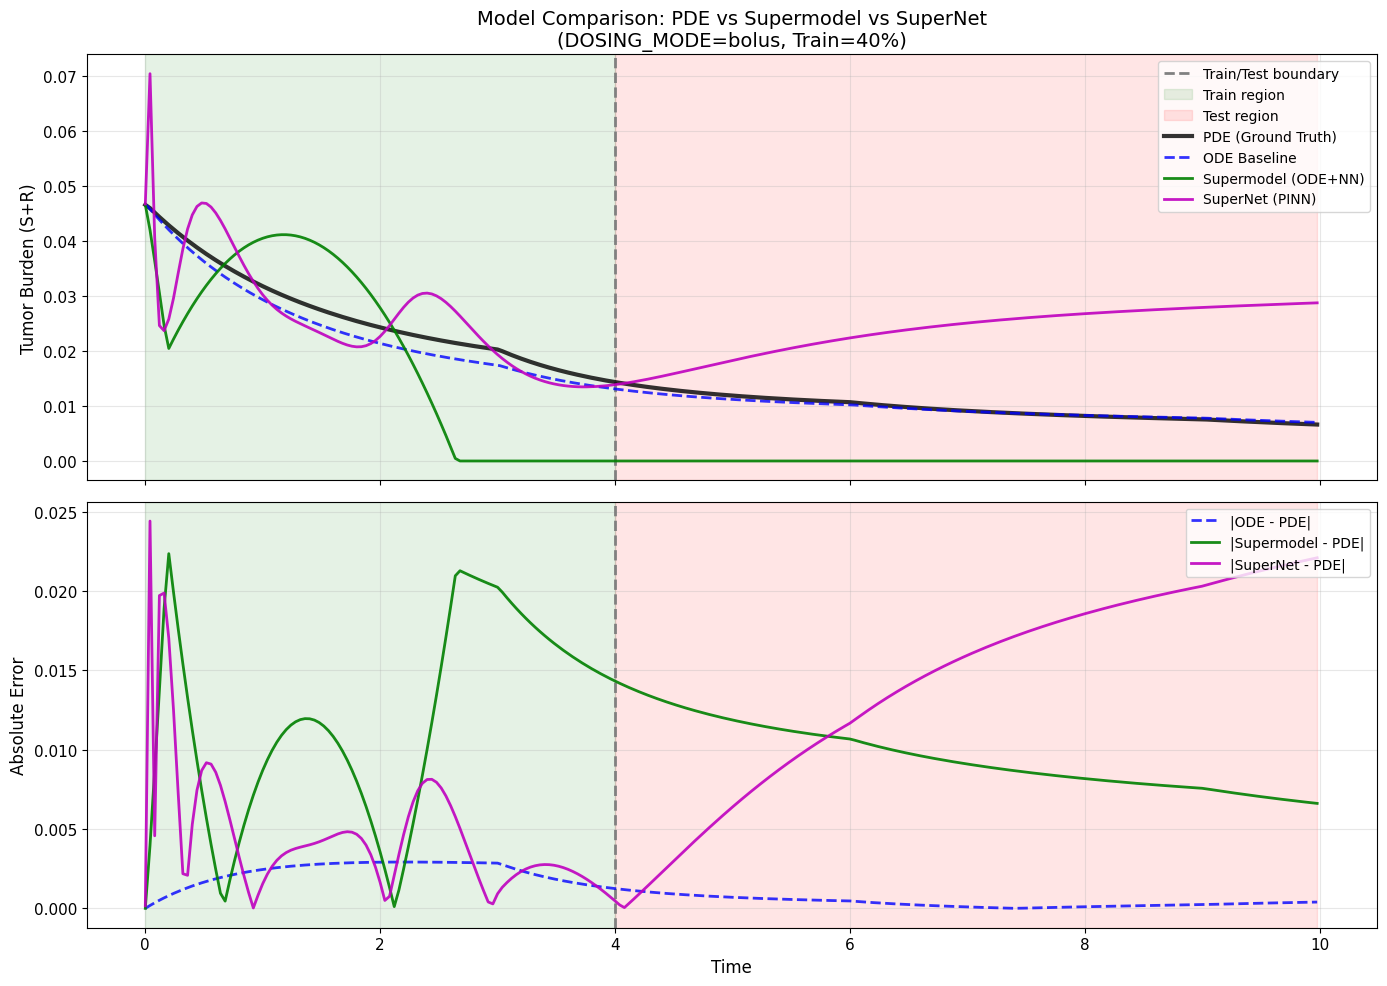

[Saved] figs/supernet_training.png


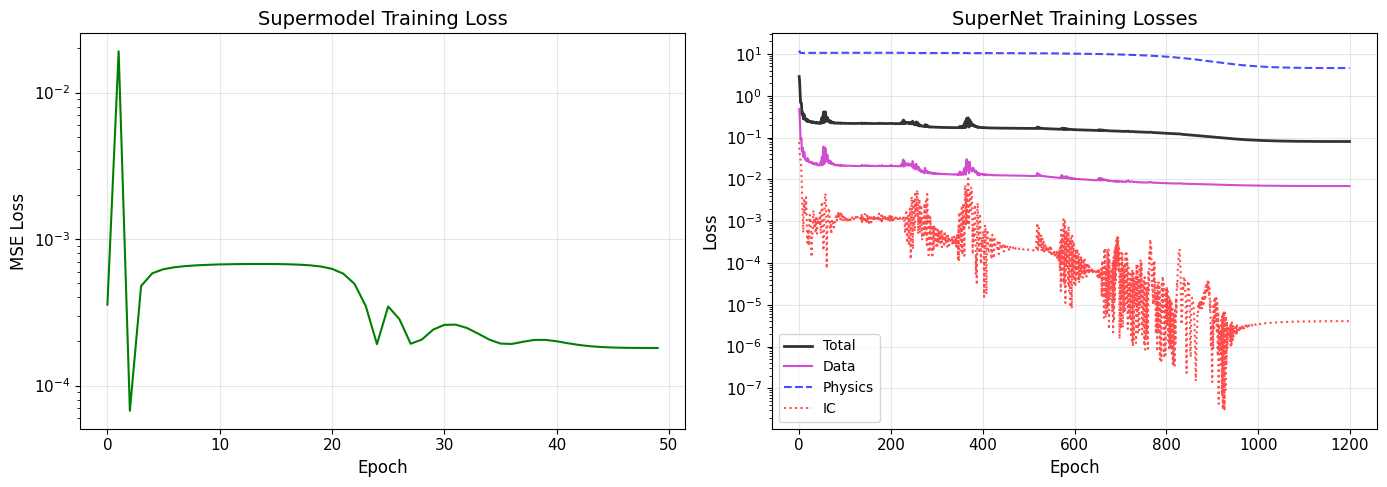

[Saved] figs/supernet_variables.png


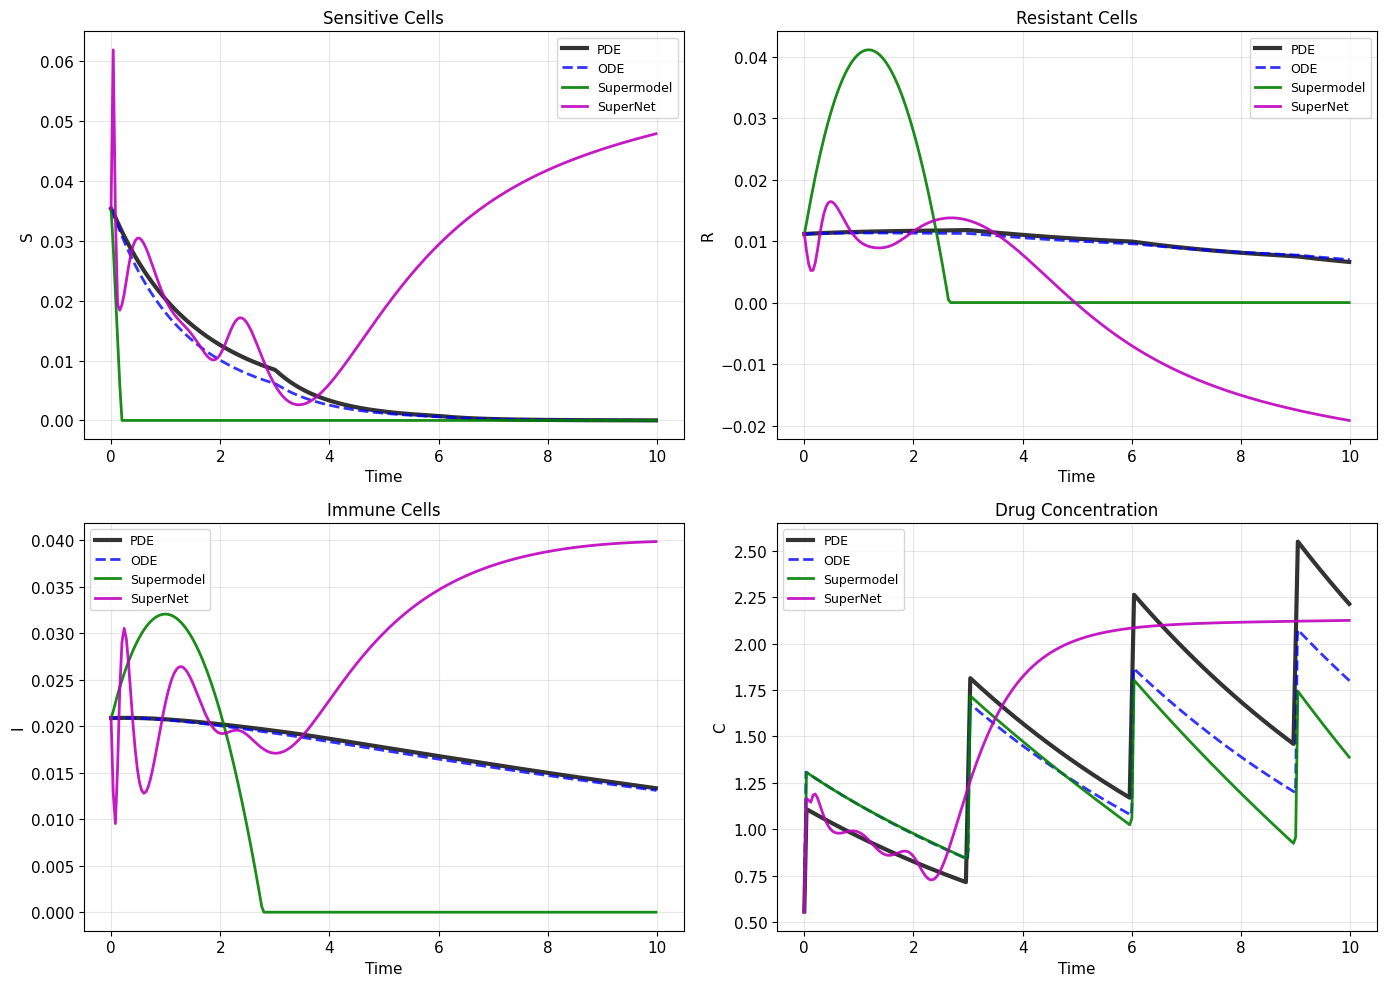


DONE! All outputs saved to figs/ and out/


In [54]:
if __name__ == "__main__":
    pde_data, ode_data, supermodel_data, supernet_data, metrics = main()